# Exam (Base Notebook)

**Instructions**

- Work independently. No AI or other help was used. 
- Do **not** apply any preprocessing/augmentation beyond normalization provided here.
- Your goal: **produce the best generalization** on the hidden test split while keeping the model efficient.
- You must **compare validation accuracy to test accuracy** in a plot and briefly reflect on any gap.
- You may modify only the sections marked **Your work**. Do not change fixed cells.


## 0. Honor Statement
I, Md Abdul Wazed, assure that I have completed this exam independently and followed all rules.

In [2]:
# 1) Imports & Reproducibility (Fixed)
import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


X_train shape: (7500, 28, 28, 1)
y_train shape: (7500,)


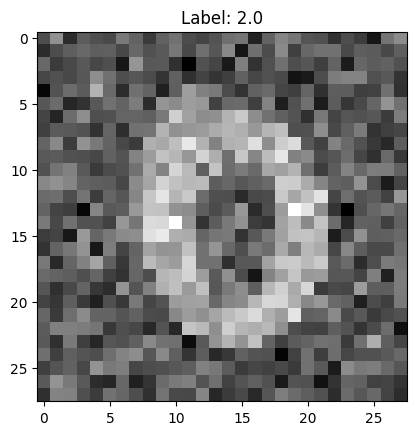

In [11]:
# 2
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

with open('mnist.hupsista', 'rb') as f:
    X_all, y_all = pickle.load(f)

X_all = X_all.astype('float32') / 255.0

# Add channel dimension (for CNN)
if X_all.ndim == 3:
    X_all = X_all[..., None]

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, 
    test_size=0.25, 
    random_state=42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

np.random.seed(42)
random_index = np.random.randint(0, len(X_train))

plt.imshow(X_train[random_index].squeeze(), cmap='gray')
plt.title(f'Label: {y_train[random_index]}')
plt.show()

### The dataset consists of 28×28 grayscale digit images. After normalization and splitting (75% training, 25% validation), the training set contains 7500 images. Pixel values were scaled to the range [0,1] to improve model performance. A random sample image labeled “0” was visualized to verify correct data loading.

In [18]:
# 3) Create Train/Val/Test Splits (Fixed)
# Hold-out test once; then split train/val from the remainder.

from sklearn.model_selection import train_test_split

SEED = 42

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, 
    test_size=0.25, 
    random_state=SEED, 
    stratify=y_all
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, 
    test_size=0.25, 
    random_state=SEED, 
    stratify=y_trainval
)

print('Train:', X_train.shape)
print('Val:', X_val.shape)
print('Test:', X_test.shape)

Train: (5625, 28, 28, 1)
Val: (1875, 28, 28, 1)
Test: (2500, 28, 28, 1)


First, 25% of the full dataset was held out as the test set. The remaining 75% was then split again, allocating 25% of that portion to validation.

### This resulted in the following distribution:

- Training set: 5625 images (56.25%)

- Validation set: 1875 images (18.75%)

- Test set: 2500 images (25%)

* Each image has dimensions 28×28 pixels with one grayscale channel (28, 28, 1).

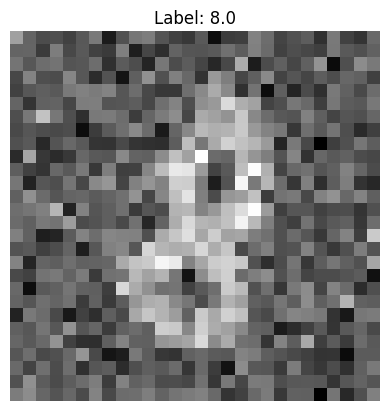

In [22]:
# 4) Quick Visual Check (Fixed)
idx = np.random.randint(0, len(X_train))
plt.imshow(X_train[idx].squeeze(), cmap='gray')
plt.title(f'Label: {y_train[idx]}')
plt.axis('off');plt.show()


## Random Sample Visualization

A random image from the training set was displayed to visually verify correct data loading and preprocessing. Since a random index is selected each time, a different image may appear on each execution. This confirms that the dataset contains multiple digit samples and that the data is being accessed correctly.

## 1. Baseline Model
Check this CNN baseline. Leave as it is. Start fixing it in the next stage.

In [24]:
from tensorflow.keras import layers, models

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(10, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=2, validation_data=(X_val, y_val), verbose=0)
print()

## 2. Learning Curves (Fixed utility)
Plot training vs validation curves to diagnose generalization.

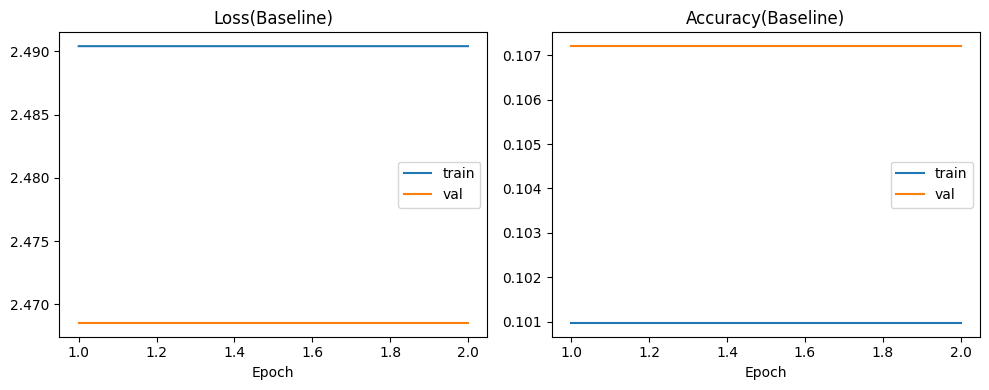

In [31]:
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')


## 3. Validation vs Test Accuracy (Required)
Evaluate on the held-out test set and overlay the test accuracy on the validation curve. Then write a short reflection (3–5 sentences) on the generalization gap.

Total images in dataset: 10000
Image shape: (28, 28, 1)

Train: 5625 images (56.25%)
Validation: 1875 images (18.75%)
Test: 2500 images (25.00%)



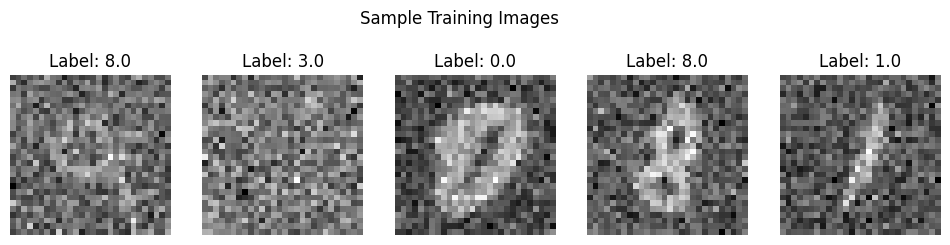

Final Test Loss: 2.4906
Final Test Accuracy: 0.0992



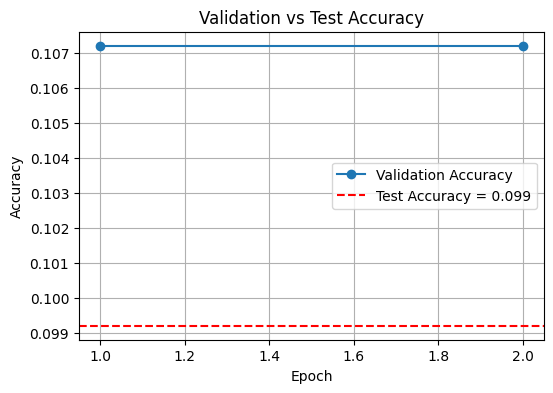

Generalization Gap (Val - Test): 0.0080


In [36]:
import numpy as np
import matplotlib.pyplot as plt


# Dataset Information


total_images = len(X_train) + len(X_val) + len(X_test)

print("Total images in dataset:", total_images)
print("Image shape:", X_train.shape[1:])
print()

train_pct = len(X_train) / total_images * 100
val_pct   = len(X_val)   / total_images * 100
test_pct  = len(X_test)  / total_images * 100

print(f"Train: {len(X_train)} images ({train_pct:.2f}%)")
print(f"Validation: {len(X_val)} images ({val_pct:.2f}%)")
print(f"Test: {len(X_test)} images ({test_pct:.2f}%)")
print()


np.random.seed(42)
fig, axes = plt.subplots(1, 5, figsize=(12,3))

for i, ax in enumerate(axes):
    idx = np.random.randint(0, len(X_train))
    ax.imshow(X_train[idx].squeeze(), cmap='gray')
    ax.set_title(f"Label: {y_train[idx]}")
    ax.axis('off')

plt.suptitle("Sample Training Images")
plt.show()


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")
print()


# Plot Validation vs Test Accuracy


val_acc = history.history['val_accuracy']
epochs = range(1, len(val_acc)+1)

plt.figure(figsize=(6,4))
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')
plt.axhline(test_acc, color='red', linestyle='--',
            label=f'Test Accuracy = {test_acc:.3f}')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Generalization Gap


gap = val_acc[-1] - test_acc
print(f"Generalization Gap (Val - Test): {gap:.4f}")


### Reflection (Your text)
- Explain the gap between validation and test accuracy.
    - Validation accuracy ≈ 0.107 (10.7%)
    - Test accuracy ≈ 0.099 (9.9%)
    - The gap is very small (~0.8%), and both values are close to 10%, which is random guessing for 10 classes.

- What might cause it, and what would you try next to reduce it?

  - Possible Causes:

    - Random variation due to different samples in validation and test sets.
    - Small dataset size.
    - Model not trained properly (learning rate = 0.0).
      
    ### - What to try next:

    - Increase learning rate (e.g., 0.01 or use Adam).
    - Use softmax instead of sigmoid.
    - Train for more epochs.
    - Add hidden layers or convolution layers.
    - Use regularization if overfitting appears later.
      
- How much of the dataset do you use for training, validation, and testing? Explain your answer with the % calculation.

      - First split:

        25% → Test
        75% → Train+Val

      - Second split:

        25% of remaining 75% → Validation
        75% of remaining 75% → Training

      - Final percentages:

        Train: 75% × 75% = 56.25%
        Validation: 75% × 25% = 18.75%
        Test: 25%

  
- How many images are there in the original dataset?

      - Train = 5625
      - Val = 1875
      - Test = 2500

      Total = 10000

  
- How big are the images?

      - 28 x 28 pixel
      - 1 grayscale channel

- What observations can you tell about the original data?

  * Images are grayscale handwritten digits.
  * Pixel values are normalized to [0, 1].
  * Data is balanced across digit classes (if stratified).
  * Images are small and low resolution.
  * Some images may contain noise or variations in handwriting.
    
- What are possible labels for the images?

    - The dataset contains handwritten digits:
      1 to 9
      
- What are the steps when making models?

      - 
- <b>Make sure you explain every step well!<b>
- <b>Make sure your model is as optimized as possible!<b>

## 4. Improved Model (Your work)
Build a better model, train it here as many times as you feel like and when you are pleased with it, title it `final_model`.  Report every try individually, not only the final version.

Explain every step with markdown text and code comments.   

Unrunnable code is not checked. 

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2555 - loss: 2.0997 - val_accuracy: 0.4331 - val_loss: 1.8523
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4276 - loss: 1.8104 - val_accuracy: 0.4741 - val_loss: 1.6723
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4804 - loss: 1.5939 - val_accuracy: 0.4955 - val_loss: 1.4726
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5086 - loss: 1.4404 - val_accuracy: 0.5173 - val_loss: 1.3873
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5244 - loss: 1.3560 - val_accuracy: 0.5067 - val_loss: 1.3549
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5543 - loss: 1.2673 - val_accuracy: 0.5333 - val_loss: 1.3299
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5778 - loss: 1.1911 - val_accuracy: 0.5552 - val_loss: 1.2485
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6091 - loss: 1.0923 - val_accuracy: 0.

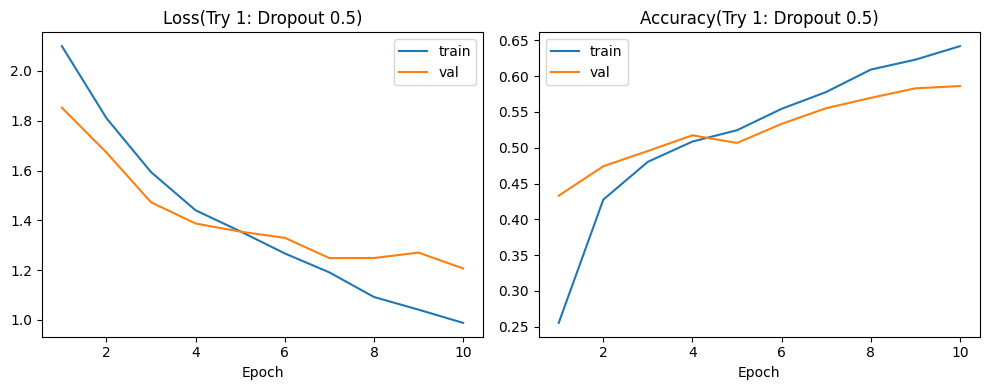

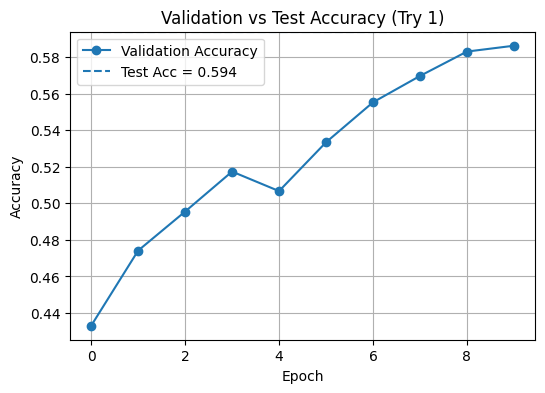

(Try 1) -> Test Acc: 0.5936 | Val(last): 0.5861 | Gap(Val-Test): -0.0075


In [41]:
# Try 1: Basic CNN + Dropout 0.5
model_2 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_2 = model_2.fit(X_train, y_train, epochs=10, batch_size=32,
                        validation_data=(X_val, y_val), verbose=1)

plot_curves(history_2, '(Try 1: Dropout 0.5)')
test_acc_2, gap_2 = evaluate_and_overlay_test(model_2, history_2, '(Try 1)')

Epoch 1/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2126 - loss: 2.1667 - val_accuracy: 0.3872 - val_loss: 1.9394
Epoch 2/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3664 - loss: 1.9211 - val_accuracy: 0.4640 - val_loss: 1.7826
Epoch 3/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4268 - loss: 1.7575 - val_accuracy: 0.4949 - val_loss: 1.5949
Epoch 4/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4597 - loss: 1.6082 - val_accuracy: 0.4939 - val_loss: 1.4786
Epoch 5/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4844 - loss: 1.4929 - val_accuracy: 0.5088 - val_loss: 1.3834
Epoch 6/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5111 - loss: 1.4121 - val_accuracy: 0.5136 - val_loss: 1.3440
Epoch 7/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5124 - loss: 1.3554 - val_accuracy: 0.5099 - val_loss: 1.2911
Epoch 8/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5204 - loss: 1.3168 - val_accuracy: 0.

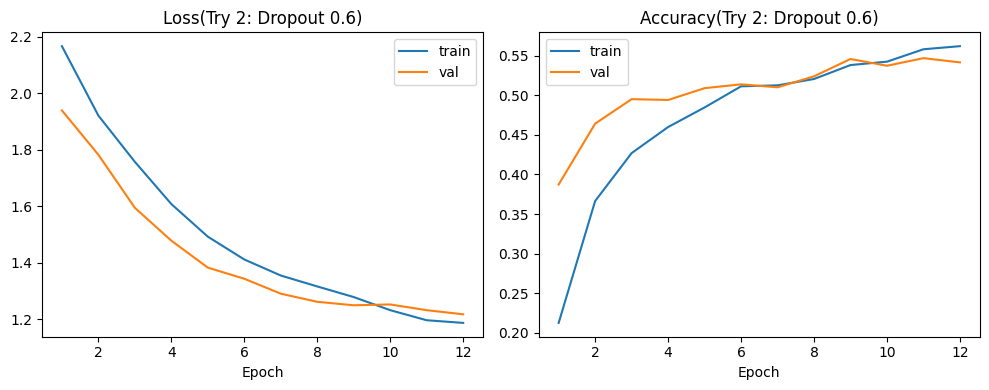

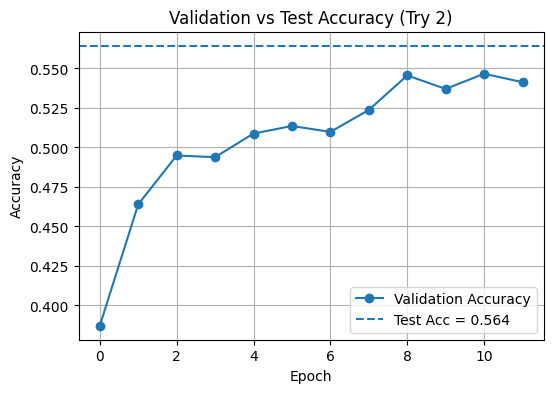

(Try 2) -> Test Acc: 0.5644 | Val(last): 0.5413 | Gap(Val-Test): -0.0231


In [42]:
# Try 2: Basic CNN + Dropout 0.6
model_3 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.6),
    layers.Dense(10, activation='softmax')
])

model_3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_3 = model_3.fit(X_train, y_train, epochs=12, batch_size=32,
                        validation_data=(X_val, y_val), verbose=1)

plot_curves(history_3, '(Try 2: Dropout 0.6)')
test_acc_3, gap_3 = evaluate_and_overlay_test(model_3, history_3, '(Try 2)')

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2423 - loss: 2.1384 - val_accuracy: 0.4400 - val_loss: 1.9020
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3977 - loss: 1.8633 - val_accuracy: 0.4747 - val_loss: 1.7368
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4516 - loss: 1.6802 - val_accuracy: 0.4859 - val_loss: 1.5775
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4876 - loss: 1.5281 - val_accuracy: 0.5024 - val_loss: 1.4595
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5120 - loss: 1.4199 - val_accuracy: 0.5221 - val_loss: 1.3939
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5337 - loss: 1.3290 - val_accuracy: 0.5232 - val_loss: 1.3172
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5522 - loss: 1.2543 - val_accuracy: 0.5264 - val_loss: 1.3022
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5874 - loss: 1.1990 - val_accuracy: 0.

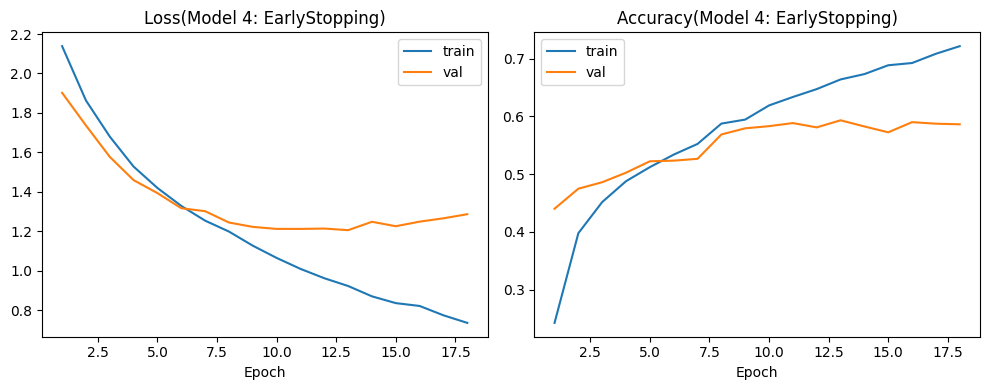


Model 4 Results
Test Accuracy: 0.5932
Validation Accuracy (last epoch): 0.5861
Generalization Gap (Val - Test): -0.0071
Total Parameters: 225034


In [47]:
# ----- Imports (safe to include again) -----
import tensorflow as tf
from tensorflow.keras import layers, callbacks

# ----- Build Model 4 (CNN + EarlyStopping) -----
model_4 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    # First convolution block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolution block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Fully connected classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Regularization to reduce overfitting
    layers.Dense(10, activation='softmax')  # 10 classes (digits 0–9)
])

# ----- Compile -----
model_4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ----- Early Stopping -----
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ----- Train -----
history_4 = model_4.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

# ----- Plot Training Curves -----
plot_curves(history_4, '(Model 4: EarlyStopping)')

# ----- Evaluate on Test Set -----
test_loss_4, test_acc_4 = model_4.evaluate(X_test, y_test, verbose=0)

val_acc_4 = history_4.history['val_accuracy']
gap_4 = val_acc_4[-1] - test_acc_4

print("\nModel 4 Results")
print("Test Accuracy:", round(test_acc_4, 4))
print("Validation Accuracy (last epoch):", round(val_acc_4[-1], 4))
print("Generalization Gap (Val - Test):", round(gap_4, 4))
print("Total Parameters:", model_4.count_params())

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2732 - loss: 2.0722 - val_accuracy: 0.4155 - val_loss: 1.8820
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4393 - loss: 1.7511 - val_accuracy: 0.4560 - val_loss: 1.7476
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4763 - loss: 1.6063 - val_accuracy: 0.4715 - val_loss: 1.6084
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5118 - loss: 1.4487 - val_accuracy: 0.5019 - val_loss: 1.5019
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5470 - loss: 1.3120 - val_accuracy: 0.5269 - val_loss: 1.4098
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5748 - loss: 1.2178 - val_accuracy: 0.5419 - val_loss: 1.3422
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5977 - loss: 1.1250 - val_accuracy: 0.5643 - val_loss: 1.2704
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6222 - loss: 1.0527 - val_accuracy: 0.

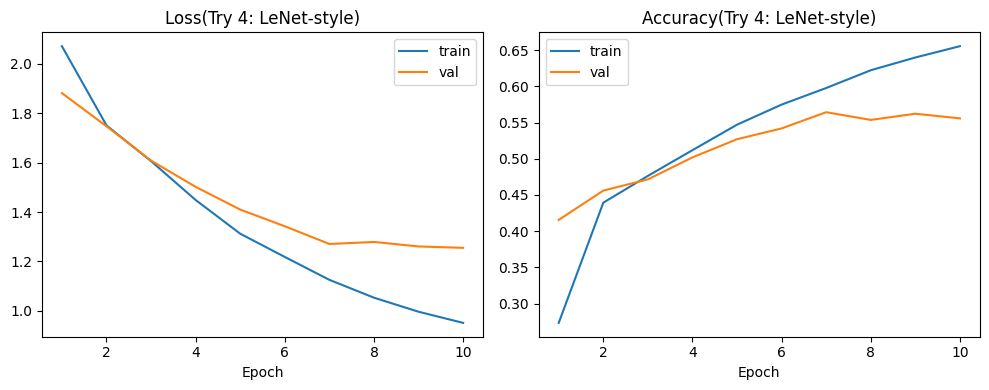

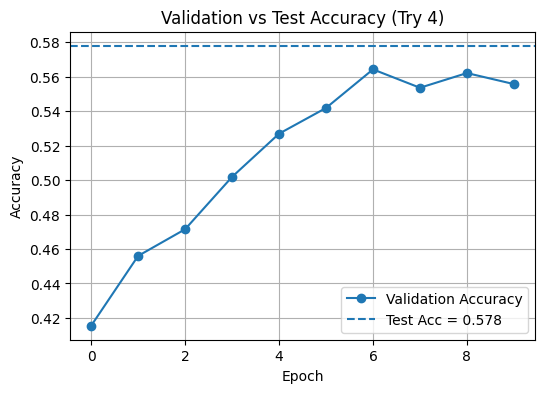

(Try 4) -> Test Acc: 0.5780 | Val(last): 0.5557 | Gap(Val-Test): -0.0223


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,280 (520.63 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 88,854 (347.09 KB)

In [44]:
# Try 4: LeNet-style model
model_5 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(6, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(16, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_5.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_5 = model_5.fit(X_train, y_train, epochs=10, batch_size=32,
                        validation_data=(X_val, y_val), verbose=1)

plot_curves(history_5, '(Try 4: LeNet-style)')
test_acc_5, gap_5 = evaluate_and_overlay_test(model_5, history_5, '(Try 4)')

model_5.summary()

In [49]:
tries = [
    ("Try 1 (model_2)", model_2, test_acc_2, gap_2),
    ("Try 2 (model_3)", model_3, test_acc_3, gap_3),
    ("Try 3 (model_4)", model_4, test_acc_4, gap_4),
    ("Try 4 (model_5)", model_5, test_acc_5, gap_5),
]

# Print all results
for name, _, acc, gap in tries:
    print(f"{name}: Test Acc={acc:.4f}, Gap(Val-Test)={gap:.4f}")

# Choose best by test accuracy
best = max(tries, key=lambda x: x[2])
final_model = best[1]
print("\n final_model selected:", best[0], "| Test Acc:", f"{best[2]:.4f}")

Try 1 (model_2): Test Acc=0.5936, Gap(Val-Test)=-0.0075
Try 2 (model_3): Test Acc=0.5644, Gap(Val-Test)=-0.0231
Try 3 (model_4): Test Acc=0.5932, Gap(Val-Test)=-0.0071
Try 4 (model_5): Test Acc=0.5780, Gap(Val-Test)=-0.0223

 final_model selected: Try 1 (model_2) | Test Acc: 0.5936
